In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
%matplotlib inline
df = pd.read_csv('retail_sales_dataset.csv')

df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")


df = pd.read_csv('retail_sales_dataset.csv')


print("--- Dataset Shape (Rows, Columns) ---")
print(df.shape)

print("\n--- Columns Data Types & Info ---")
print(df.info())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataset Shape (Rows, Columns) ---
(1000, 9)

--- Columns Data Types & Info ---
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 70.4 KB
None

--- Missing Values Count ---
Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64


In [5]:
# 1. Date column
df['Date'] = pd.to_datetime(df['Date'])

# 2. Numerical columns
print("--- Summary Statistics ---")
df.describe()

--- Summary Statistics ---


,Transaction ID,Date,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,2023-07-03 00:25:55.200000,41.39200,2.514000,179.890000,456.000000
min,1.000000,2023-01-01 00:00:00,18.00000,1.000000,25.000000,25.000000
25%,250.750000,2023-04-08 00:00:00,29.00000,1.000000,30.000000,60.000000
50%,500.500000,2023-06-29 12:00:00,42.00000,3.000000,50.000000,135.000000
75%,750.250000,2023-10-04 00:00:00,53.00000,4.000000,300.000000,900.000000
max,1000.000000,2024-01-01 00:00:00,64.00000,4.000000,500.000000,2000.000000
std,288.819436,NaN,13.68143,1.132734,189.681356,559.997632


In [6]:
# Descriptive Statistics - Mode
print("--- Mode of Numerical Columns ---")
print(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].mode().iloc[0])

--- Mode of Numerical Columns ---
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


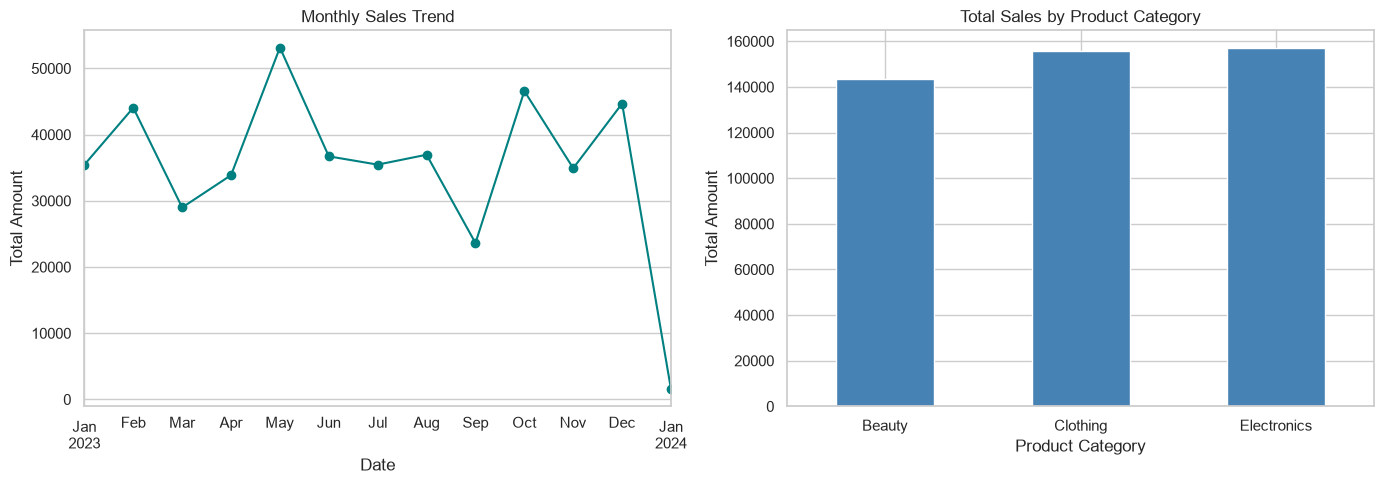

In [7]:
# Visualizations: Sales Trend & Product Performance
plt.figure(figsize=(14, 5))

# 1. Monthly Sales Trend Chart
plt.subplot(1, 2, 1)
df.set_index('Date').resample('ME')['Total Amount'].sum().plot(kind='line', marker='o', color='teal')
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Amount')

# 2. Product Category-wise Sales
plt.subplot(1, 2, 2)
df.groupby('Product Category')['Total Amount'].sum().plot(kind='bar', color='steelblue')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation — Monthly & Category Sales
- Peak sales occurred in May (~53,000), indicating strong seasonal demand
- September recorded the lowest sales (~23,000) of the year
- Electronics and Clothing are the top performing categories
- Beauty category is closely competitive with other categories

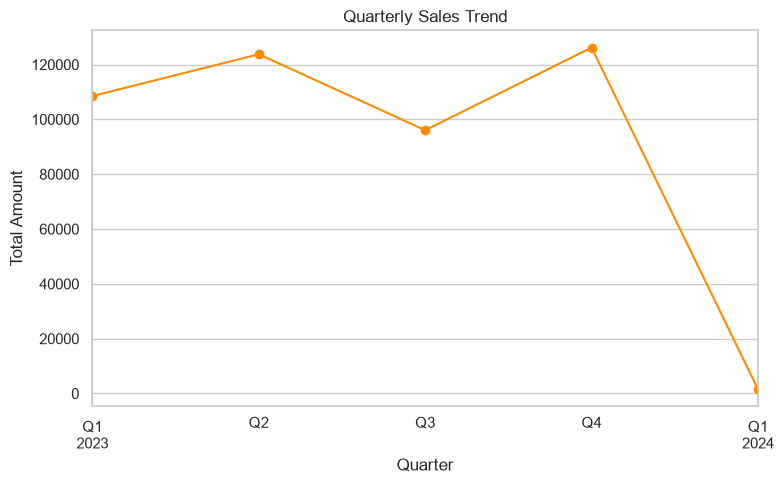

In [8]:
# Quarterly Sales Trend
plt.figure(figsize=(8, 5))

df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date').resample('QE')['Total Amount'].sum().plot(
    kind='line', 
    marker='o', 
    color='darkorange'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

### Observation — Quarterly Trend
- Q2 (April-June) is the strongest quarter in terms of revenue
- Q3 (July-September) shows a clear decline in sales
- Q4 shows recovery trend towards the end of the year

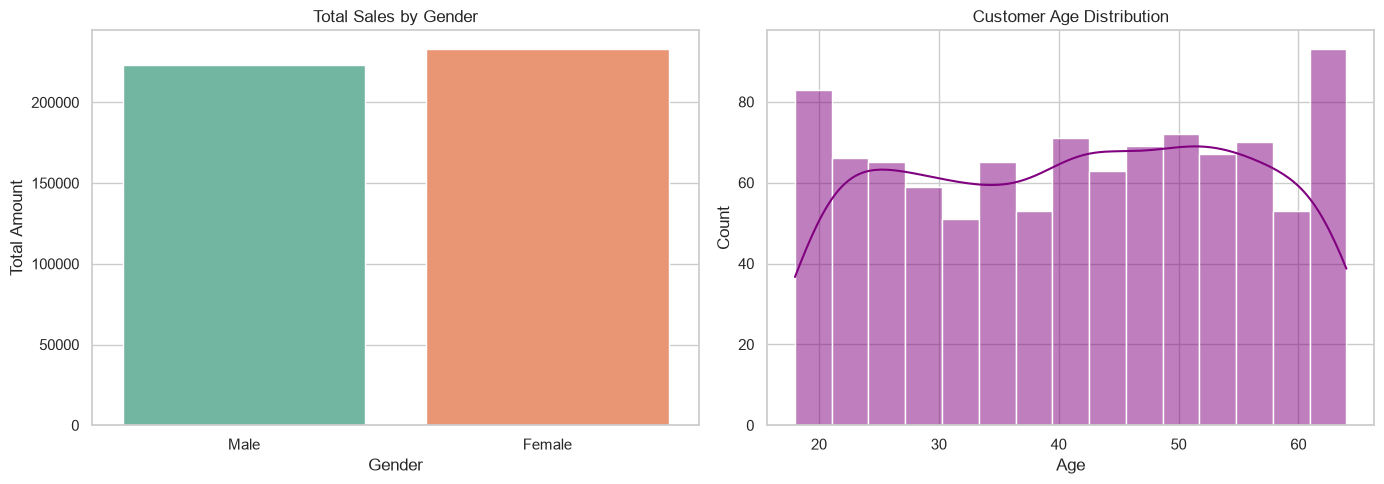

In [9]:
# Visualizations: Gender Sales & Age Distribution
plt.figure(figsize=(14, 5))

# 1. Total Sales by Gender
plt.subplot(1, 2, 1)
sns.barplot(x='Gender', y='Total Amount', data=df, estimator=sum, errorbar=None, hue='Gender', palette='Set2', legend=False)
plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Amount')

# 2. Customer Age Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['Age'], bins=15, kde=True, color='purple')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### Observation — Customer Demographics
- Revenue distribution is nearly equal between Male and Female customers
- Female customers contribute slightly higher total sales
- Customer age is evenly distributed between 18 and 64 years

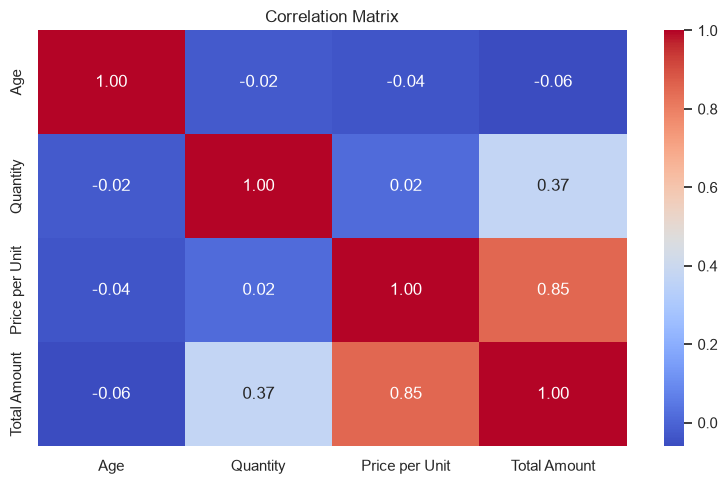

In [10]:
# Correlation Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

### Observation — Correlation Analysis
- Price per Unit and Total Amount show strong positive correlation
- Age and Quantity show no significant correlation
- Quantity and Total Amount have a moderate positive correlation

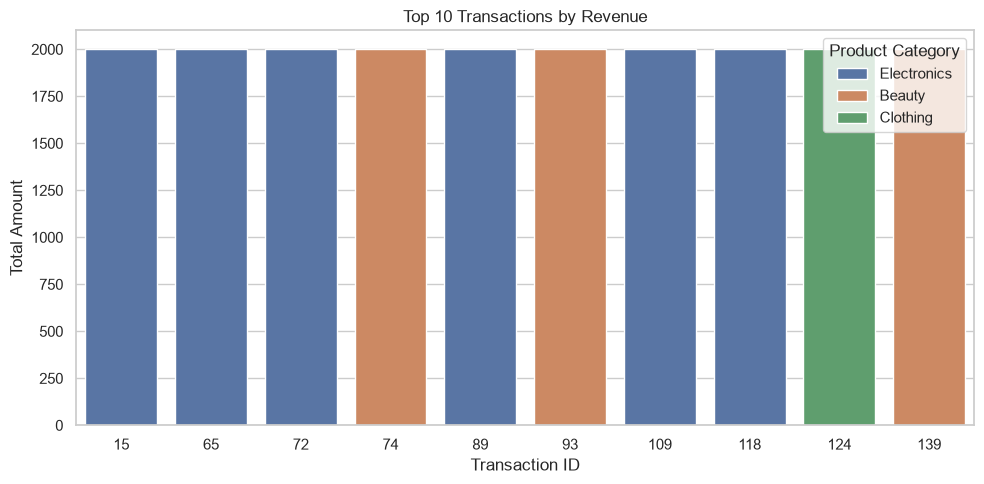

In [11]:
# Top 10 Transactions by Total Amount
plt.figure(figsize=(10, 5))
top10 = df.nlargest(10, 'Total Amount')[['Transaction ID', 'Product Category', 'Total Amount']]
sns.barplot(x='Transaction ID', y='Total Amount', hue='Product Category', data=top10)
plt.title('Top 10 Transactions by Revenue')
plt.xlabel('Transaction ID')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

### Observation — Top 10 Transactions
- Top 10 highest transactions are mostly from Electronics 
  and Beauty categories
- Maximum transaction value reaches up to 2,000
- Clothing appears less frequently in top transactions
- High value transactions are spread across different customers

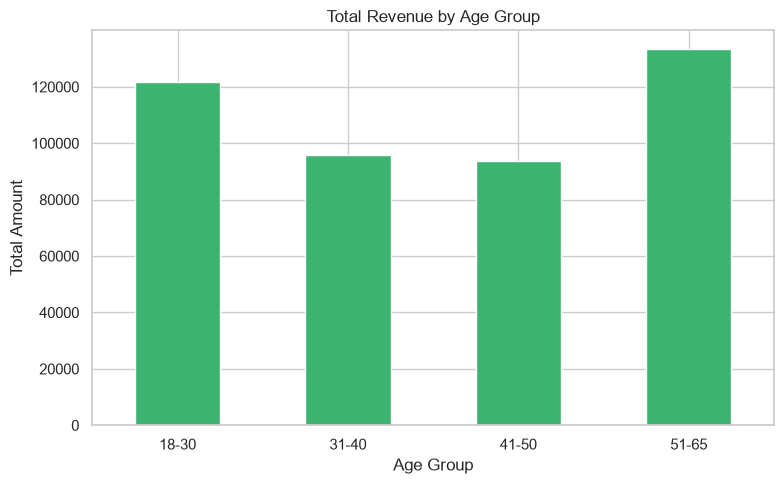

In [12]:
# Revenue by Age Group
df['Age Group'] = pd.cut(df['Age'], 
    bins=[18, 30, 40, 50, 65], 
    labels=['18-30', '31-40', '41-50', '51-65']
)

plt.figure(figsize=(8, 5))
df.groupby('Age Group', observed=True)['Total Amount'].sum().plot(
    kind='bar', 
    color='mediumseagreen'
)
plt.title('Total Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Observation — Age Group Analysis
- The 41-50 age group contributes the highest total revenue
- The 18-30 age group ranks second in total purchases
- The 51-65 age group shows comparatively lower purchasing activity

# Executive Summary & Exploratory Data Analysis Report

## 1. Key Findings

- **Data Quality:** The dataset contains 1,000 transactions with 
  zero missing values, ensuring high data integrity.

- **Monthly Trends:** Peak sales occurred in May (~53,000), 
  while the lowest sales were recorded in September (~23,000).

- **Quarterly Trends:** Q2 (April-June) generated the highest 
  revenue. A noticeable decline was observed in Q3, followed 
  by recovery in Q4.

- **Category Performance:** Electronics (156,905) and Clothing 
  (155,580) are the top performing categories. Beauty (143,515) 
  ranks third.

- **Customer Demographics:** Female customers contribute slightly 
  higher total sales. Customer age is evenly distributed 
  between 18 and 64 years.

- **Age Group Insight:** The 41-50 age group contributes the 
  highest total revenue across all age segments.

- **Correlation:** Price per Unit and Total Amount show a 
  strong positive correlation.

## 2. Actionable Recommendations

- **Off-Peak Campaigns:** Launch promotional discounts during 
  September and March to stabilize revenue in low-performing months.

- **Inventory Planning:** Ensure sufficient stock of Electronics 
  and Clothing before May to meet Q2 peak demand.

- **Age-Based Marketing:** Focus targeted campaigns on the 41-50 
  age group as they generate the highest revenue.